# Exploring Feature Distributions from Pedestrian Trajectories

## Design notes

**Why image space, not WGS84?**  
Homography transforms pixel coordinates to geographic coordinates by fitting a projective transform to ground control points. This transform introduces distortion that grows with distance from the GCP convex hull — so pixel-space speed and acceleration are more reliable than WGS84-derived values for behavioral analysis.

**Depth normalization via bbox_height**  
A person far from the camera occupies fewer pixels than one close by, even at the same real-world speed. To compensate, each per-step pixel distance is multiplied by a scale factor derived from the average bounding box height at that step:

```
scale [m/px]           = H_REAL / avg_bbox_height_px
real_speed [m/s]       = pixel_speed [px/s]  x scale
real_accel [m/s^2]     = diff(real_speed)    / dt
real_displacement [m]  = pixel_disp * avg_scale(endpoints)
```

Assumption: standard human height H_REAL = 1.7 m. Breaks down for occluded persons.

**Excluded features**  
Direction: the camera is tilted at an angle, so apparent direction in pixel space reflects camera geometry, not the pedestrian's heading. Not comparable across locations.

**Features extracted per trajectory**

| Feature | Unit | Description |
|---|---|---|
| `real_speed_mean` | m/s | Mean walking speed (depth-normalized) |
| `real_speed_std` | m/s | Speed variability |
| `real_speed_cv` | — | Coefficient of variation (std/mean) |
| `real_dist_total` | m | Total path length |
| `real_accel_abs_mean` | m/s² | Mean absolute acceleration (depth-normalized) |
| `stop_ratio` | — | Fraction of steps below 0.5 m/s |
| `real_straightness` | — | Depth-normalized displacement / total real path length |
| `speed_skew` | — | Within-trajectory skewness of per-step speeds |
| `decel_ratio` | — | Fraction of acceleration steps that are negative |
| `duration_sec` | s | Observation duration |


In [14]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, lognorm, halfnorm, expon, beta
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

H_REAL       = 1.7    # assumed human height [m]
STOP_MS      = 0.3    # near-stop threshold [m/s]
DATA_DIR     = Path('../output/trajectory')
output_dir   = Path('../output/analysis/explore_distributions_pixel')
TARGET_VIDEO = '2394'
output_dir.mkdir(parents=True, exist_ok=True)
from scipy.stats import gamma, uniform, laplace, cauchy, t as t

## 1. Load data

In [15]:
with open(DATA_DIR / f'{TARGET_VIDEO}_analysis.json') as f:
    data = json.load(f)

tracks = data['tracks']
fps    = data['fps']
print(f"Video      : {data['video_name']}")
print(f"FPS        : {fps}")
print(f"Resolution : {data['resolution']}")
print(f"Tracks     : {len(tracks)}")
print()
sample = tracks[0]['trajectory'][0]
print(f"Trajectory point keys: {list(sample.keys())}")
print(f"Example            : {sample}")

Video      : 2394.mp4
FPS        : 29
Resolution : 1920x1080
Tracks     : 618

Trajectory point keys: ['x', 'y', 'frame', 'time_sec', 'bbox_height']
Example            : {'x': 489, 'y': 869, 'frame': 1, 'time_sec': 0.034, 'bbox_height': 387}


## 2. Feature extraction

In [16]:
def extract_features(track, min_points=4):
    traj = track.get('trajectory', [])
    if len(traj) < min_points:
        return None

    times        = np.array([p['time_sec']                for p in traj])
    xs           = np.array([p['x']                       for p in traj])
    ys           = np.array([p['y']                       for p in traj])
    bbox_heights = np.array([p.get('bbox_height', np.nan) for p in traj])

    px_dists  = np.sqrt(np.diff(xs)**2 + np.diff(ys)**2)
    dts       = np.maximum(np.diff(times), 1e-6)
    px_speeds = px_dists / dts

    has_bbox = not np.any(np.isnan(bbox_heights))
    if has_bbox:
        avg_h       = np.maximum((bbox_heights[:-1] + bbox_heights[1:]) / 2, 1)
        scales      = H_REAL / avg_h
        real_dists  = px_dists * scales
        real_speeds = real_dists / dts

        real_speed_mean = float(np.mean(real_speeds))
        real_speed_std  = float(np.std(real_speeds))
        real_speed_cv   = real_speed_std / real_speed_mean if real_speed_mean > 1e-6 else 0.0
        real_dist_total = float(np.sum(real_dists))
        stop_ratio      = float(np.mean(real_speeds < STOP_MS))
        speed_skew      = float(stats.skew(real_speeds))

        # depth-normalized displacement -> real_straightness
        sc0 = H_REAL / max(bbox_heights[0],  1)
        sc1 = H_REAL / max(bbox_heights[-1], 1)
        avg_sc            = (sc0 + sc1) / 2
        real_displace     = float(np.sqrt(((xs[-1]-xs[0])*avg_sc)**2 + ((ys[-1]-ys[0])*avg_sc)**2))
        real_straightness = real_displace / real_dist_total if real_dist_total > 1e-6 else 1.0

        if len(real_speeds) >= 2:
            dts2             = np.maximum((dts[:-1] + dts[1:]) / 2, 1e-6)
            accels           = np.diff(real_speeds) / dts2   # signed, m/s^2
            real_accel_abs_mean = float(np.mean(np.abs(accels)))
            real_accel_mean  = float(np.mean(accels))
            real_accel_std   = float(np.std(accels))
            real_accel_cv    = real_accel_std / real_accel_abs_mean if real_accel_abs_mean > 1e-6 else 0.0
            decel_ratio      = float(np.mean(accels < 0))
        else:
            real_accel_abs_mean = real_accel_mean = real_accel_std = real_accel_cv = np.nan
            decel_ratio = np.nan
    else:
        real_speed_mean = real_speed_std = real_speed_cv = real_dist_total = np.nan
        real_accel_abs_mean = real_accel_mean = real_accel_std = real_accel_cv = np.nan
        stop_ratio = float(np.mean(px_speeds < 5.0))
        speed_skew = real_straightness = decel_ratio = np.nan

    if len(px_speeds) < 2:
        return None
    duration_sec = float(times[-1] - times[0])

    return dict(
        id                  = track['id'],
        real_speed_mean     = real_speed_mean,
        real_speed_std      = real_speed_std,
        real_speed_cv       = real_speed_cv,
        real_dist_total     = real_dist_total,
        real_accel_abs_mean = real_accel_abs_mean,
        real_accel_mean     = real_accel_mean,
        real_accel_std      = real_accel_std,
        real_accel_cv       = real_accel_cv,
        stop_ratio          = stop_ratio,
        speed_skew          = speed_skew,
        real_straightness   = real_straightness,
        decel_ratio         = decel_ratio,
        duration_sec        = duration_sec,
        n_points            = len(traj),
    )


records = [r for r in (extract_features(t) for t in tracks) if r is not None]
df  = pd.DataFrame(records)
df_r = df.dropna(subset=['real_speed_mean'])

print(f"Tracks after filtering : {len(df)}")
print(f"With bbox_height       : {len(df_r)}")
df_r[['real_speed_mean', 'real_accel_abs_mean', 'speed_skew', 'real_straightness', 'decel_ratio']].describe()

Tracks after filtering : 618
With bbox_height       : 618


,real_speed_mean,real_accel_abs_mean,speed_skew,real_straightness,decel_ratio
count,618.000000,618.000000,618.000000,618.000000,618.000000
mean,1.386085,23.537235,2.473830,0.526816,0.499207
std,0.486481,11.756354,2.034154,0.362709,0.053945
min,0.413780,4.692684,-0.395355,0.009044,0.272727
25%,1.085178,16.758499,1.069354,0.249413,0.468085
50%,1.343818,20.872803,1.946196,0.474920,0.500000
75%,1.607908,27.444304,3.179103,0.723051,0.525987
max,4.792465,115.492810,11.926786,2.861287,0.769231


## 3. Real-world speed distribution

Typical pedestrian walking speed: **1.0–1.5 m/s**. Use this as a sanity check.

**How to read `real_speed_mean`**

| Value (m/s) | Interpretation |
|---|---|
| < 0.5 | Near-stop or very slow drift |
| 0.5–1.0 | Slow walking (distracted, browsing) |
| 1.0–1.5 | Normal walking — expected majority |
| 1.5–2.0 | Fast walking (purposeful) |
| > 2.0 | Running or tracking artifact |

**How to read `real_speed_cv`** (std / mean, unitless)

| Value | Interpretation |
|---|---|
| < 0.2 | Steady, consistent pace |
| 0.2–0.5 | Moderate variability (typical) |
| > 0.5 | Erratic speed changes — stopping, hesitating, or rushing |

For intervention analysis (Article 12–13): a shift toward lower `real_speed_mean`
or higher `real_speed_cv` near a stimulus indicates disrupted flow.


In [17]:
def compare_fits(ax_hist, ax_ks, data, title, candidates, bounded=False):
    """
    Fit and plot multiple distributions.
    bounded=True : clip data to [0.001, 0.999], skip quantile filter (for [0,1] features).
    bounded=False: filter d > 0 and d < quantile(0.99) (for positive-unbounded features).
    Returns (best_name, best_ks, best_pv, best_params).
    """
    d = data.dropna()
    if bounded:
        d = d.clip(0.001, 0.999)
    else:
        d = d[d < d.quantile(0.99)]
    x_lo = 0.001 if bounded else (d.min() if d.min() > 0 else -d.std() * 3)
    x_hi = 0.999 if bounded else d.quantile(0.99)
    x = np.linspace(x_lo, x_hi, 300)

    ax_hist.hist(d, bins=60, density=True, alpha=0.45, color='gray', label='data')

    results = []
    colors = ['r', 'g', 'b', 'm']
    for (name, fit_fn, pdf_fn, cdf_fn), col in zip(candidates, colors):
        params = fit_fn(d)
        ax_hist.plot(x, pdf_fn(x, *params), f'{col}-', lw=2, label=name)
        ks, pv = stats.kstest(d, lambda x, p=params, f=cdf_fn: f(x, *p))
        results.append((name, round(ks, 4), round(pv, 4), params))

    ax_hist.set_title(title)
    ax_hist.set_ylabel('Density')
    ax_hist.legend(fontsize=8)

    labels  = [r[0] for r in results]
    ks_vals = [r[1] for r in results]
    pv_vals = [r[2] for r in results]

    bars = ax_ks.bar(labels, ks_vals, color=colors[:len(labels)], alpha=0.7)
    ax_ks.set_ylabel('KS statistic  (lower = better)')
    ax_ks.set_title(f'{title} — KS')
    for bar, pv_val in zip(bars, pv_vals):
        ax_ks.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                   f'p={pv_val:.3f}', ha='center', fontsize=9)

    best = min(results, key=lambda r: (r[1], -r[2]))
    return best  # (name, ks, pv, params)


def fit_best(series, candidates, bounded=False):
    """
    Same preprocessing as compare_fits but without plotting.
    Used for features that don't have a dedicated compare_fits plot cell.
    Returns (best_name, best_ks, best_pv, best_params).
    """
    d = series.dropna()
    if bounded:
        d = d.clip(0.001, 0.999)
    else:
        d = d[d < d.quantile(0.99)]
    results = []
    for name, fit_fn, pdf_fn, cdf_fn in candidates:
        params = fit_fn(d)
        ks, pv = stats.kstest(d, lambda x, p=params, f=cdf_fn: f(x, *p))
        results.append((name, round(ks, 4), round(pv, 4), params))
    return min(results, key=lambda r: (r[1], -r[2]))


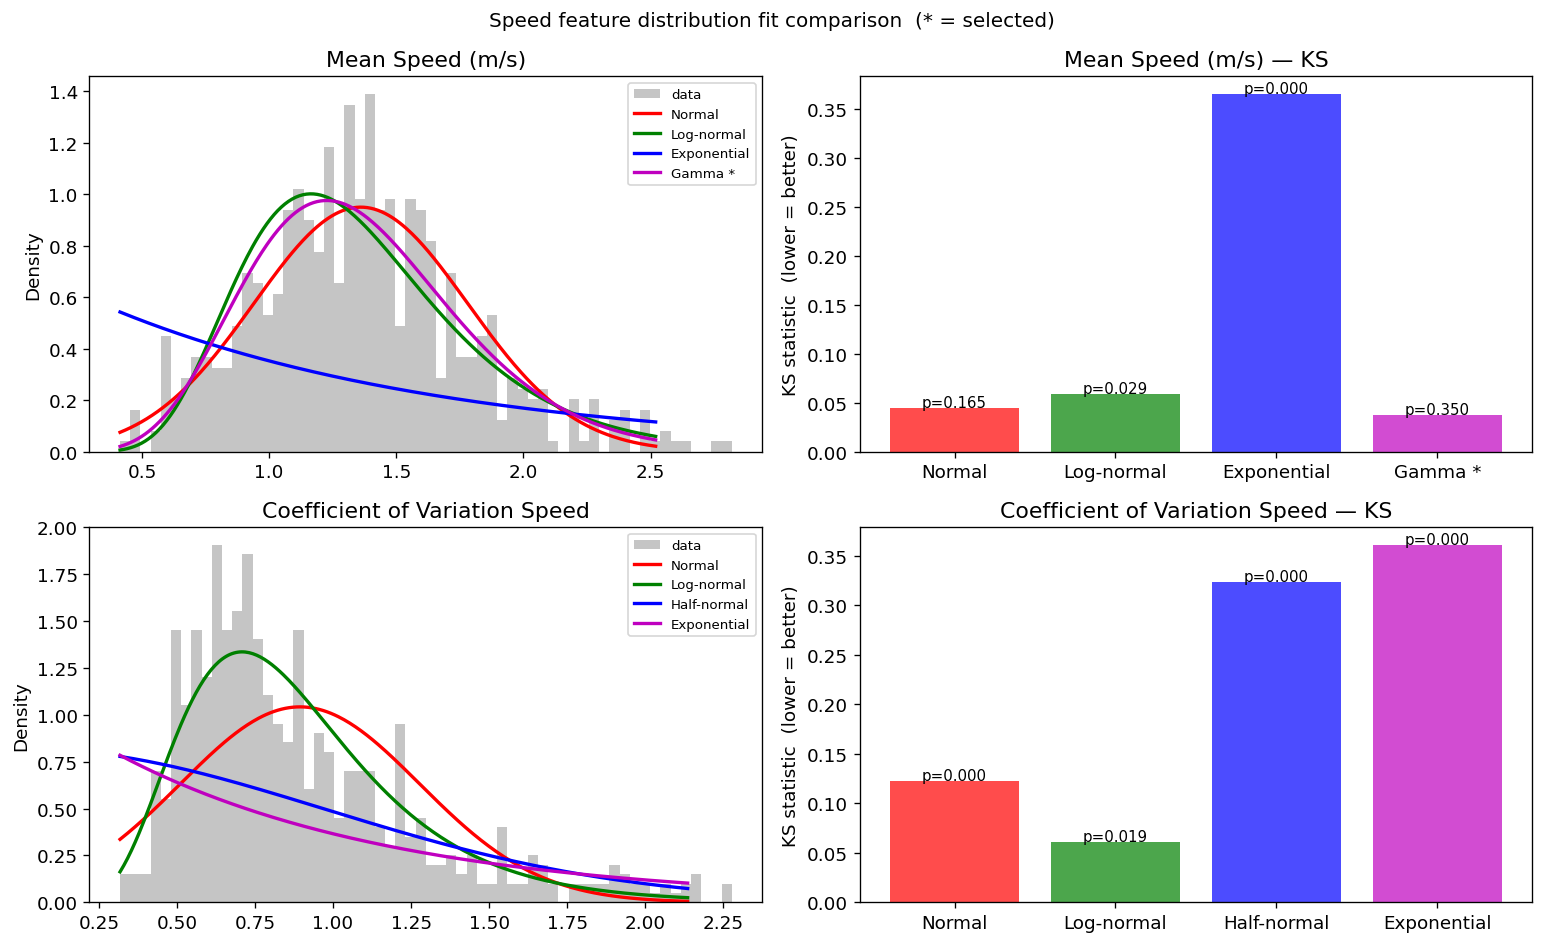

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))


compare_fits(axes[0, 0], axes[0, 1], df_r['real_speed_mean'], 'Mean Speed (m/s)', [
    ('Normal', norm.fit, norm.pdf, norm.cdf),
    ('Log-normal', lambda d: lognorm.fit(d, floc=0), lognorm.pdf, lambda x, *p: lognorm.cdf(x, *p)),
    # ('Half-normal', lambda d: halfnorm.fit(d, floc=0), halfnorm.pdf, lambda x, *p: halfnorm.cdf(x, *p)),
    ('Exponential', lambda d: expon.fit(d, floc=0), expon.pdf, lambda x, *p: expon.cdf(x, *p)),
    ('Gamma *',    lambda d: gamma.fit(d, floc=0), lambda x, *p: gamma.pdf(x, *p), lambda x, *p: gamma.cdf(x, *p)),
])

# compare_fits(axes[1, 0], axes[1, 1], df_r['real_speed_std'], 'Std Speed (m/s)', [
#     ('Normal', norm.fit, norm.pdf, norm.cdf),
#     ('Log-normal', lambda d: lognorm.fit(d, floc=0), lognorm.pdf, lambda x, *p: lognorm.cdf(x, *p)),
#     ('Half-normal', lambda d: halfnorm.fit(d, floc=0), halfnorm.pdf, lambda x, *p: halfnorm.cdf(x, *p)),
#     ('Exponential', lambda d: expon.fit(d, floc=0), expon.pdf, lambda x, *p: expon.cdf(x, *p)),
# ])

compare_fits(axes[1, 0], axes[1, 1], df_r['real_speed_cv'], 'Coefficient of Variation Speed', [
    ('Normal', norm.fit, norm.pdf, norm.cdf),
    ('Log-normal', lambda d: lognorm.fit(d, floc=0), lognorm.pdf, lambda x, *p: lognorm.cdf(x, *p)),
    ('Half-normal', lambda d: halfnorm.fit(d, floc=0), halfnorm.pdf, lambda x, *p: halfnorm.cdf(x, *p)),
    ('Exponential', lambda d: expon.fit(d, floc=0), expon.pdf, lambda x, *p: expon.cdf(x, *p)),
])

plt.suptitle('Speed feature distribution fit comparison  (* = selected)', fontsize=12)
plt.tight_layout()
plt.savefig(output_dir / f'{TARGET_VIDEO}_speed_distribution_fits.png', dpi=150, bbox_inches='tight')
plt.show()


In [19]:
output_dir/f'{TARGET_VIDEO}_real_speed_mean_distribution_fits.png'

WindowsPath('../output/analysis/explore_distributions_pixel/2394_real_speed_mean_distribution_fits.png')

## 4. Acceleration distribution

Mean absolute acceleration in **m/s²** (depth-normalized via bbox_height, same as speed).  
Captures how much a person speeds up and slows down — primary indicator of behavioral change.

**How to read `real_accel_abs_mean`** (mean of |accel|)

| Value (m/s²) | Interpretation |
|---|---|
| < 5 | Very smooth, constant-speed walking |
| 5–20 | Normal walking with natural speed variation |
| 20–50 | Frequent braking / accelerating (crowds, obstacles) |
| > 50 | Strong behavioral disruption, abrupt stops, or tracking noise |

**How to read `real_accel_mean`** (signed mean, ~0 for steady walking)

- ≈ 0: person neither systematically accelerates nor decelerates
- Negative: net deceleration over the trajectory (person slowed down overall)
- Positive: net acceleration (person sped up overall)

**How to read `real_accel_std`** (variability of signed acceleration)

High std = large swings between acceleration and deceleration.  
Captures "jerkiness" of motion independent of mean speed.

For intervention analysis: `real_accel_abs_mean` is the most sensitive single indicator.
A rise near a stimulus = people braking and correcting course.


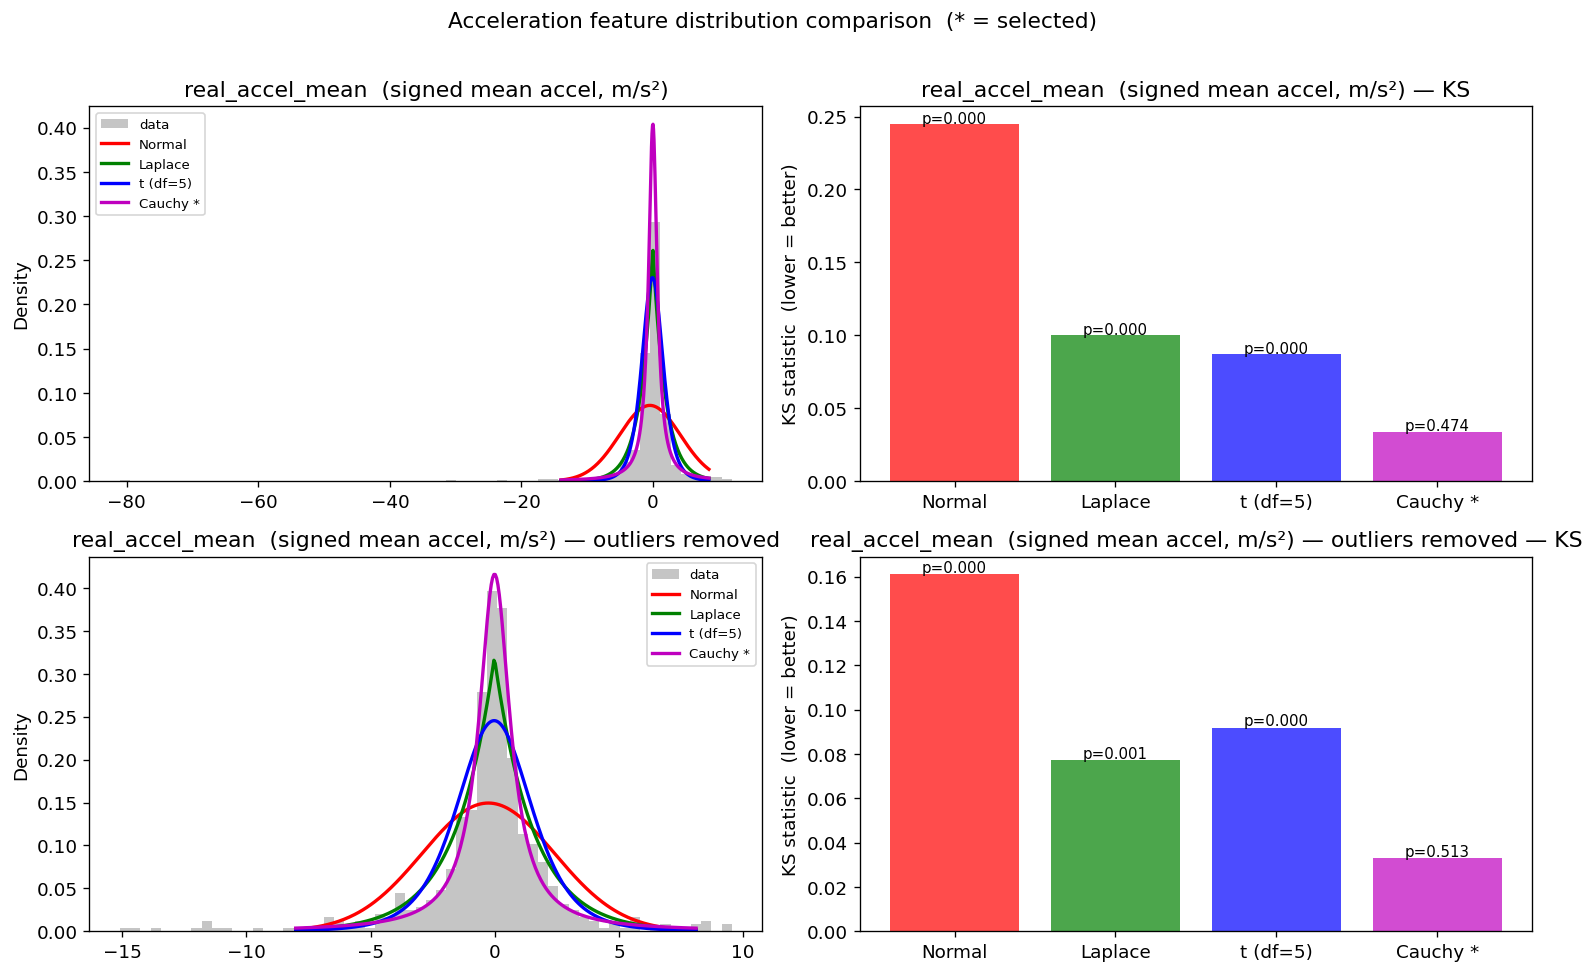

In [20]:
from scipy.stats import laplace, cauchy, t

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
# --- real_accel_abs_mean: mean of |accel|, positive → halfnorm / exponential / lognormal ---
# compare_fits(
#     axes[0, 0], axes[0, 1],
#     df_r['real_accel_abs_mean'],
#     'real_accel_abs_mean  (mean |accel|, m/s²)',
#     [
#         ('Half-normal', lambda d: halfnorm.fit(d, floc=0),
#          lambda x, *p: halfnorm.pdf(x, *p), lambda x, *p: halfnorm.cdf(x, *p)),
#         ('Exponential', lambda d: (*expon.fit(d, floc=0),),
#          lambda x, *p: expon.pdf(x, *p),    lambda x, *p: expon.cdf(x, *p)),
#         ('Log-normal',  lambda d: lognorm.fit(d, floc=0),
#          lambda x, *p: lognorm.pdf(x, *p),  lambda x, *p: lognorm.cdf(x, *p)),
#     ]
# )

# --- real_accel_mean: signed mean → Cauchy (selected) ---

compare_fits(
    axes[0, 0], axes[0, 1],
    df_r['real_accel_mean'],
    'real_accel_mean  (signed mean accel, m/s²)',
    [
        ('Normal',   lambda d: norm.fit(d),   lambda x, *p: norm.pdf(x, *p),   lambda x, *p: norm.cdf(x, *p)),
        ('Laplace',  lambda d: laplace.fit(d), lambda x, *p: laplace.pdf(x, *p), lambda x, *p: laplace.cdf(x, *p)),
        ('t (df=5)', lambda d: t.fit(d, f0=5), lambda x, *p: t.pdf(x, *p),      lambda x, *p: t.cdf(x, *p)),
        ('Cauchy *', lambda d: cauchy.fit(d),  lambda x, *p: cauchy.pdf(x, *p), lambda x, *p: cauchy.cdf(x, *p)),
    ]
)
compare_fits(
    axes[1, 0], axes[1, 1],
    df_r['real_accel_mean'][abs(df_r['real_accel_mean'] - df_r['real_accel_mean'].mean()) < df_r['real_accel_mean'].std()*3],
    'real_accel_mean  (signed mean accel, m/s²) — outliers removed',
    [
        ('Normal',   lambda d: norm.fit(d),   lambda x, *p: norm.pdf(x, *p),   lambda x, *p: norm.cdf(x, *p)),
        ('Laplace',  lambda d: laplace.fit(d), lambda x, *p: laplace.pdf(x, *p), lambda x, *p: laplace.cdf(x, *p)),
        ('t (df=5)', lambda d: t.fit(d, f0=5), lambda x, *p: t.pdf(x, *p),      lambda x, *p: t.cdf(x, *p)),
        ('Cauchy *', lambda d: cauchy.fit(d),  lambda x, *p: cauchy.pdf(x, *p), lambda x, *p: cauchy.cdf(x, *p)),
    ]
)



# --- real_accel_std: std of signed accel, positive → halfnorm / lognormal ---
# compare_fits(
#     axes[2, 0], axes[2, 1],
#     df_r['real_accel_std'],
#     'real_accel_std  (std of accel, m/s²)',
#     [
#         ('Half-normal', lambda d: halfnorm.fit(d, floc=0),
#          lambda x, *p: halfnorm.pdf(x, *p), lambda x, *p: halfnorm.cdf(x, *p)),
#         ('Log-normal',  lambda d: lognorm.fit(d, floc=0),
#          lambda x, *p: lognorm.pdf(x, *p),  lambda x, *p: lognorm.cdf(x, *p)),
#     ]
# )

# # --- real_accel_cv: coefficient of variation of accel, positive → halfnorm / lognormal ---
# compare_fits(
#     axes[3, 0], axes[3, 1],
#     df_r['real_accel_cv'],
#     'real_accel_cv  (coefficient of variation of accel)',
#     [
#         ('Half-normal', lambda d: halfnorm.fit(d, floc=0),
#          lambda x, *p: halfnorm.pdf(x, *p), lambda x, *p: halfnorm.cdf(x, *p)),
#         ('Log-normal',  lambda d: lognorm.fit(d, floc=0),
#          lambda x, *p: lognorm.pdf(x, *p),  lambda x, *p: lognorm.cdf(x, *p)),
#     ]
# )

plt.suptitle('Acceleration feature distribution comparison  (* = selected)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(output_dir / f'{TARGET_VIDEO}_accel_distribution_fits.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Stop ratio distribution

Fraction of steps where real-world speed < 0.5 m/s.  
A high stop ratio flags people who paused — potentially reacting to a stimulus.

**How to read `stop_ratio`**

| Value | Interpretation |
|---|---|
| 0 | Never stopped — continuous flow |
| 0–0.05 | Momentary hesitation |
| 0.05–0.20 | Noticeable pausing (reading a sign, looking around) |
| > 0.20 | Sustained stopping — strong behavioral disruption |

Complementary to `speed_skew` and `decel_ratio`: all three together describe
different facets of slowing-down behavior.

Note: threshold 0.5 m/s is set in `STOP_MS`. Adjust if the scene contains
very slow-moving crowds where 0.5 m/s is not a reliable stop criterion.


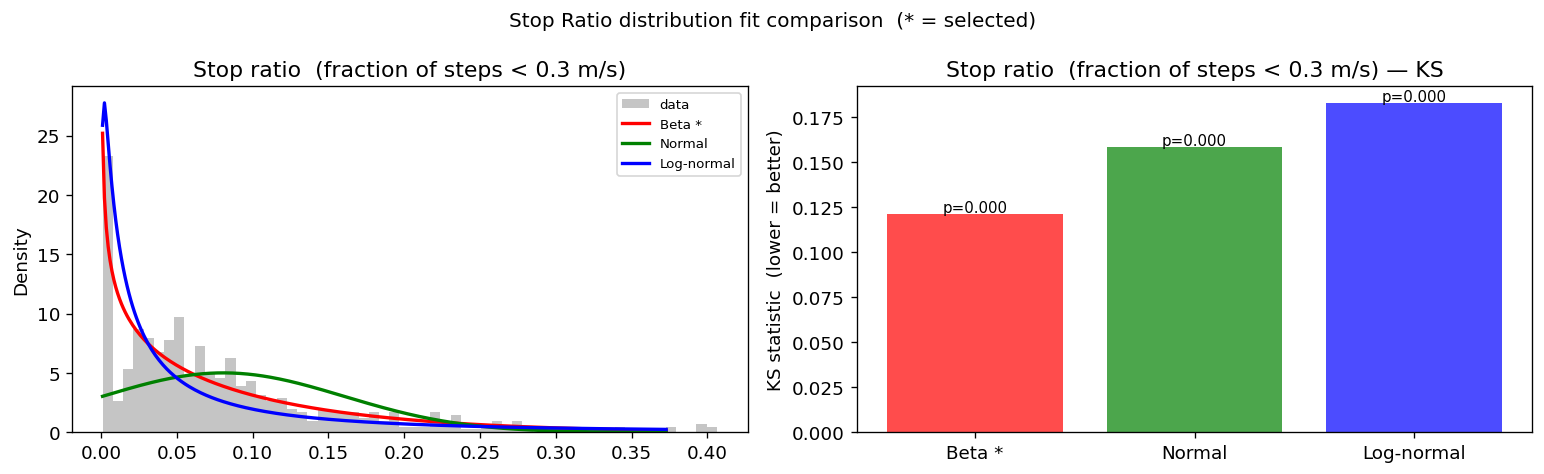

Fraction with any stop   : 100.0%
Fraction with >20% stop  : 10.0%


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sr = df_r['stop_ratio'].dropna().clip(0.001, 0.999)

compare_fits(axes[0], axes[1], sr,
    f'Stop ratio  (fraction of steps < {STOP_MS} m/s)',
    [
        ('Beta *',     lambda d: beta.fit(d, floc=0, fscale=1),
         lambda x, *p: beta.pdf(np.clip(x,0.001,0.999), *p), lambda x, *p: beta.cdf(np.clip(x,0.001,0.999), *p)),
        # ('Uniform',    lambda d: uniform.fit(d, floc=0, fscale=1),
        #  lambda x, *p: uniform.pdf(x, *p), lambda x, *p: uniform.cdf(x, *p)),
        ('Normal',     lambda d: norm.fit(d),
         lambda x, *p: norm.pdf(x, *p),    lambda x, *p: norm.cdf(x, *p)),
        ('Log-normal', lambda d: lognorm.fit(d, floc=0),
         lambda x, *p: lognorm.pdf(x, *p), lambda x, *p: lognorm.cdf(x, *p)),
    ]
)

plt.suptitle('Stop Ratio distribution fit comparison  (* = selected)', fontsize=12)
plt.tight_layout()
plt.savefig(output_dir / f'{TARGET_VIDEO}_stop_ratio_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Fraction with any stop   : {(sr > 0).mean():.1%}')
print(f'Fraction with >20% stop  : {(sr > 0.2).mean():.1%}')

## 6. Path straightness distribution

Ratio of depth-normalized displacement to total real path length.  
Values near 1 = beeline; values near 0 = circling, reversing, or wandering.

**How to read `real_straightness`**

| Value | Interpretation |
|---|---|
| > 0.9 | Nearly straight — purposeful, unobstructed flow |
| 0.6–0.9 | Slight deviation (natural pedestrian weaving) |
| 0.3–0.6 | Significant winding (obstacles, crowding, hesitation) |
| < 0.3 | Strong deviation — turning back, circling, or very short track |

Depth normalization matters when a person moves toward or away from the camera:
pixel-space displacement would undercount or overcount real-world displacement
without the bbox_height correction applied here.

For intervention analysis: a drop in `real_straightness` near a stimulus
indicates people deviating from their intended path.


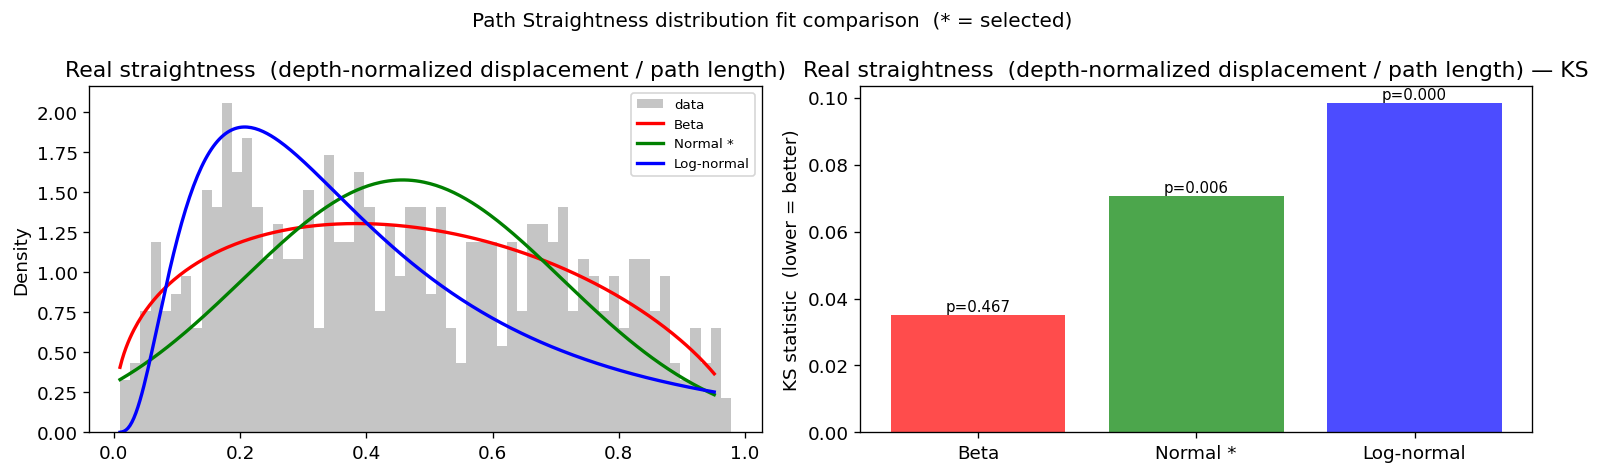

Median real_straightness : 0.475
Fraction > 0.9 (straight): 10.5%
Fraction < 0.3 (winding) : 30.4%


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

st = df_r['real_straightness'].dropna().clip(0.01, 0.99)

_best_straightness = compare_fits(axes[0], axes[1], st,
    'Real straightness  (depth-normalized displacement / path length)',
    [
        ('Beta',        lambda d: beta.fit(d, floc=0, fscale=1),
         lambda x, *p: beta.pdf(np.clip(x,0.001,0.999), *p), lambda x, *p: beta.cdf(np.clip(x,0.001,0.999), *p)),
        # ('Uniform',     lambda d: uniform.fit(d, floc=0, fscale=1),
        #  lambda x, *p: uniform.pdf(x, *p), lambda x, *p: uniform.cdf(x, *p)),
        ('Normal *',    lambda d: norm.fit(d),
         lambda x, *p: norm.pdf(x, *p),    lambda x, *p: norm.cdf(x, *p)),
        ('Log-normal',  lambda d: lognorm.fit(d, floc=0),
         lambda x, *p: lognorm.pdf(x, *p), lambda x, *p: lognorm.cdf(x, *p)),
    ],
    bounded=False
)

plt.suptitle('Path Straightness distribution fit comparison  (* = selected)', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Median real_straightness : {st.median():.3f}')
print(f'Fraction > 0.9 (straight): {(st > 0.9).mean():.1%}')
print(f'Fraction < 0.3 (winding) : {(st < 0.3).mean():.1%}')

## 7. Duration distribution

Observation duration of each track in seconds.

**How to read `duration_sec`**

| Value (s) | Interpretation |
|---|---|
| < 1 | Partial track (entered/exited frame quickly) — low reliability |
| 1–5 | Standard crossing (one side of frame to the other) |
| 5–15 | Slower traversal, stopping, or diagonal crossing |
| > 15 | Extended dwell — person lingering, waiting, or following a long path |

Short tracks are more likely to be truncated by the frame boundary.
Consider filtering to `duration_sec > 1.0` for manifold construction
to reduce boundary artifacts.

Correlation with other features: long duration often co-occurs with
low `real_speed_mean` and high `stop_ratio`.


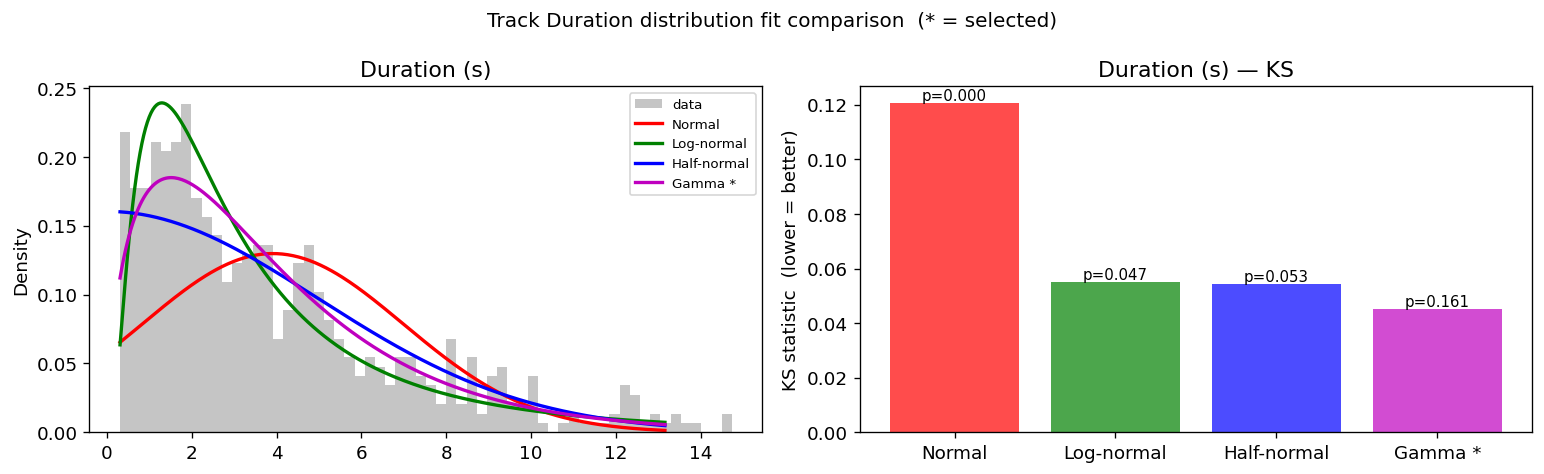

Median duration   : 3.1 s
90th percentile   : 8.6 s


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

dur = df['duration_sec'].dropna()
dur = dur[dur > 0.1]

_best_duration = compare_fits(axes[0], axes[1], dur, 'Duration (s)',
    [
        ('Normal',      lambda d: norm.fit(d),
         lambda x, *p: norm.pdf(x, *p),       lambda x, *p: norm.cdf(x, *p)),
        ('Log-normal',  lambda d: lognorm.fit(d, floc=0),
         lambda x, *p: lognorm.pdf(x, *p),    lambda x, *p: lognorm.cdf(x, *p)),
        ('Half-normal', lambda d: halfnorm.fit(d, floc=0),
         lambda x, *p: halfnorm.pdf(x, *p),   lambda x, *p: halfnorm.cdf(x, *p)),
        ('Gamma *',     lambda d: gamma_dist.fit(d, floc=0),
         lambda x, *p: gamma_dist.pdf(x, *p), lambda x, *p: gamma_dist.cdf(x, *p)),
    ]
)

plt.suptitle('Track Duration distribution fit comparison  (* = selected)', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Median duration   : {dur.median():.1f} s')
print(f'90th percentile   : {dur.quantile(0.9):.1f} s')

## 8. Speed skew distribution

Within-trajectory skewness of per-step real speeds.  
Captures the temporal shape of the speed profile — did the person slow down or speed up?

**How to read `speed_skew`**

| Value | Interpretation |
|---|---|
| ≈ 0–1 | Slight right skew — typical steady walking (speed floor at 0 creates natural right tail) |
| 1–3 | Moderate right skew — occasional slow steps against a fast baseline |
| > 3 | Strong right skew — brief stops or very uneven speed profile |
| < 0 | Left skew — rare (1.6% of tracks); fast burst followed by slowdown |

Note: because per-step speed is bounded below by 0, within-trajectory speed distributions
are inherently right-skewed. As a result, `speed_skew` is almost always positive
(98.4% of tracks), making **Gamma** the appropriate population distribution.

For intervention analysis: a systematic shift toward higher `speed_skew` near a stimulus
indicates people alternating between normal walking and abrupt stops.


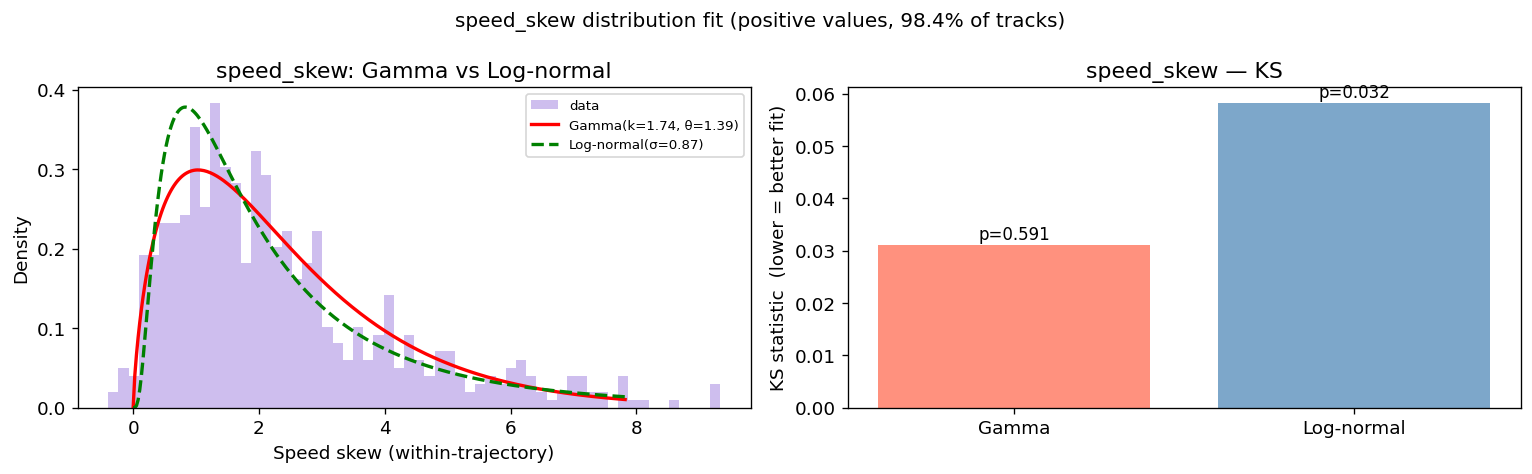

Gamma      KS=0.0312  p=0.5913  k=1.74  theta=1.39
Log-normal KS=0.0583  p=0.0322
Fraction negative (excluded from fit): 1.6%


In [24]:
from scipy.stats import gamma as gamma_dist

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sk = df_r['speed_skew'].dropna()
sk = sk[sk < sk.quantile(0.99)]  # trim extreme outliers for display
sk_pos = sk[sk > 0]              # gamma fit on positive values (99.4% of data)
x = np.linspace(0, sk.quantile(0.99), 300)

ax = axes[0]
ax.hist(sk, bins=60, density=True, alpha=0.45, color='mediumpurple', label='data')

# Gamma fit
a_gm, loc_gm, sc_gm = gamma_dist.fit(sk_pos, floc=0)
ax.plot(x, gamma_dist.pdf(x, a_gm, loc_gm, sc_gm), 'r-', lw=2,
        label=f'Gamma(k={a_gm:.2f}, θ={sc_gm:.2f})')

# Log-normal fit
sh_ln, loc_ln, sc_ln = lognorm.fit(sk_pos, floc=0)
ax.plot(x, lognorm.pdf(x, sh_ln, loc_ln, sc_ln), 'g--', lw=2,
        label=f'Log-normal(σ={sh_ln:.2f})')

ax.set_xlabel('Speed skew (within-trajectory)')
ax.set_ylabel('Density')
ax.set_title('speed_skew: Gamma vs Log-normal')
ax.legend(fontsize=8)

ax2 = axes[1]
ks_gm, pv_gm = stats.kstest(sk_pos, lambda x: gamma_dist.cdf(x, a_gm, loc_gm, sc_gm))
ks_ln, pv_ln = stats.kstest(sk_pos, lambda x: lognorm.cdf(x, sh_ln, loc_ln, sc_ln))
ax2.bar(['Gamma', 'Log-normal'], [ks_gm, ks_ln],
        color=['tomato', 'steelblue'], alpha=0.7)
ax2.set_ylabel('KS statistic  (lower = better fit)')
ax2.set_title('speed_skew — KS')
for i, (ks, pv) in enumerate([(ks_gm, pv_gm), (ks_ln, pv_ln)]):
    ax2.text(i, ks + 0.001, f'p={pv:.3f}', ha='center', fontsize=10)

plt.suptitle('speed_skew distribution fit (positive values, 98.4% of tracks)', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Gamma      KS={ks_gm:.4f}  p={pv_gm:.4f}  k={a_gm:.2f}  theta={sc_gm:.2f}")
print(f"Log-normal KS={ks_ln:.4f}  p={pv_ln:.4f}")
print(f"Fraction negative (excluded from fit): {(sk <= 0).mean():.1%}")

# store best fit result for KS summary
_best_speed_skew = ('Gamma', ks_gm, pv_gm, (a_gm, loc_gm, sc_gm))


## 9. Decel ratio distribution

Fraction of acceleration steps where acceleration is negative (decelerating).  
Captures how often a person brakes relative to accelerating.

**How to read `decel_ratio`**

| Value | Interpretation |
|---|---|
| ≈ 0.5 | Balanced: accelerating and decelerating equally (steady walking) |
| > 0.6 | Predominantly decelerating — braking behavior, approaching stops |
| < 0.4 | Predominantly accelerating — person speeding up throughout |

Complements `real_accel_abs_mean` (intensity) with frequency:
together they describe both "how often" and "how strongly" a person changes speed.

For intervention analysis: if `decel_ratio` shifts above 0.5 near a stimulus,
people are braking more than they are accelerating — a signature of approach inhibition.


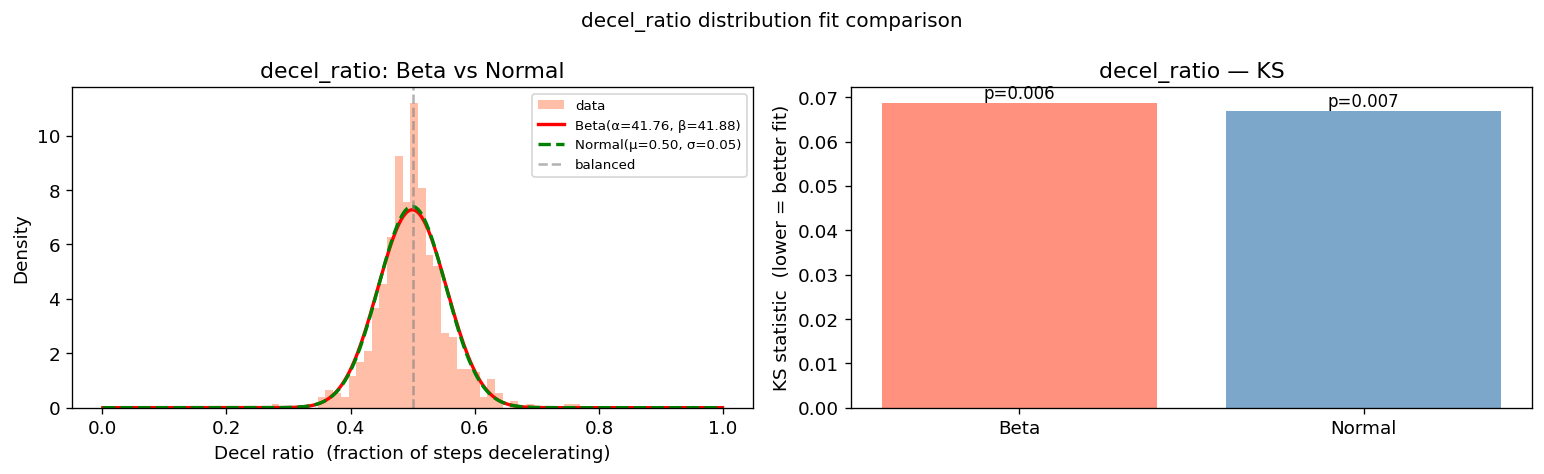

Beta    KS=0.0688  p=0.0055  alpha=41.76  beta=41.88
Normal  KS=0.0669  p=0.0075
Median decel_ratio               : 0.500
Fraction > 0.5 (net decelerating): 42.7%


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

dr = df_r['decel_ratio'].dropna().clip(0.001, 0.999)

ax = axes[0]
ax.hist(dr, bins=40, density=True, alpha=0.5, color='coral', label='data')
a_dr, b_dr, lo_dr, sc_dr = beta.fit(dr, floc=0, fscale=1)
x = np.linspace(0.001, 0.999, 300)
ax.plot(x, beta.pdf(x, a_dr, b_dr, lo_dr, sc_dr), 'r-', lw=2,
        label=f'Beta(α={a_dr:.2f}, β={b_dr:.2f})')
mu_dr, sig_dr = norm.fit(dr)
ax.plot(x, norm.pdf(x, mu_dr, sig_dr), 'g--', lw=2,
        label=f'Normal(μ={mu_dr:.2f}, σ={sig_dr:.2f})')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.6, label='balanced')
ax.set_xlabel('Decel ratio  (fraction of steps decelerating)')
ax.set_ylabel('Density')
ax.set_title('decel_ratio: Beta vs Normal')
ax.legend(fontsize=8)

ax2 = axes[1]
ks_dr_b, pv_dr_b = stats.kstest(dr, lambda x: beta.cdf(np.clip(x, 0.001, 0.999), a_dr, b_dr, lo_dr, sc_dr))
ks_dr_n, pv_dr_n = stats.kstest(dr, lambda x: norm.cdf(x, mu_dr, sig_dr))
ax2.bar(['Beta', 'Normal'], [ks_dr_b, ks_dr_n],
        color=['tomato', 'steelblue'], alpha=0.7)
ax2.set_ylabel('KS statistic  (lower = better fit)')
ax2.set_title('decel_ratio — KS')
for j, (ks, pv) in enumerate([(ks_dr_b, pv_dr_b), (ks_dr_n, pv_dr_n)]):
    ax2.text(j, ks + 0.001, f'p={pv:.3f}', ha='center', fontsize=10)

plt.suptitle('decel_ratio distribution fit comparison', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Beta    KS={ks_dr_b:.4f}  p={pv_dr_b:.4f}  alpha={a_dr:.2f}  beta={b_dr:.2f}")
print(f"Normal  KS={ks_dr_n:.4f}  p={pv_dr_n:.4f}")
print(f"Median decel_ratio               : {dr.median():.3f}")
print(f"Fraction > 0.5 (net decelerating): {(dr > 0.5).mean():.1%}")

## 10. Goodness-of-fit (KS test)

In [26]:
# ── Candidate sets (reused by fit_best for features without compare_fits plots) ──
_cands_positive = [
    ('Normal',     lambda d: norm.fit(d),              lambda x,*p: norm.pdf(x,*p),              lambda x,*p: norm.cdf(x,*p)),
    ('Log-normal', lambda d: lognorm.fit(d, floc=0),   lambda x,*p: lognorm.pdf(x,*p),           lambda x,*p: lognorm.cdf(x,*p)),
    ('Gamma',      lambda d: gamma_dist.fit(d, floc=0),lambda x,*p: gamma_dist.pdf(x,*p),        lambda x,*p: gamma_dist.cdf(x,*p)),
    ('Half-normal',lambda d: halfnorm.fit(d, floc=0),  lambda x,*p: halfnorm.pdf(x,*p),          lambda x,*p: halfnorm.cdf(x,*p)),
]
_cands_bounded = [
    ('Beta',   lambda d: beta.fit(d, floc=0, fscale=1),
               lambda x,*p: beta.pdf(np.clip(x,0.001,0.999),*p),
               lambda x,*p: beta.cdf(np.clip(x,0.001,0.999),*p)),
    ('Normal', lambda d: norm.fit(d), lambda x,*p: norm.pdf(x,*p), lambda x,*p: norm.cdf(x,*p)),
]
_cands_full_real = [
    ('Normal', lambda d: norm.fit(d),   lambda x,*p: norm.pdf(x,*p),  lambda x,*p: norm.cdf(x,*p)),
    ('Cauchy', lambda d: cauchy.fit(d), lambda x,*p: cauchy.pdf(x,*p),lambda x,*p: cauchy.cdf(x,*p)),
]

df_r = df.dropna(subset=['real_speed_mean'])

# Features without a dedicated compare_fits plot cell
from scipy.stats import cauchy
_best_speed_mean = fit_best(df_r['real_speed_mean'],  _cands_positive)
_best_speed_cv   = fit_best(df_r['real_speed_cv'],    _cands_positive)
_best_accel_mean = fit_best(df_r['real_accel_mean'],  _cands_full_real)
_best_stop_ratio = fit_best(df_r['stop_ratio'],       _cands_bounded,  bounded=True)
_best_decel = fit_best(df_r['decel_ratio'],         _cands_bounded,  bounded=True)

# Collect all results (plot cells must be run first for _best_* variables)
rows = []
for feat, result in [
    ('real_speed_mean',     _best_speed_mean),
    ('real_speed_cv',       _best_speed_cv),
    # ('real_accel_abs_mean', _best_accel_abs),
    ('real_accel_mean',     _best_accel_mean),
    ('stop_ratio',          _best_stop_ratio),
    ('real_straightness',   _best_straightness),
    ('speed_skew',          _best_speed_skew),
    ('decel_ratio',         _best_decel),
    ('duration_sec',        _best_duration),
]:
    name, ks, pv, params = result
    rows.append({
        'feature':      feat,
        'distribution': name,
        'KS statistic': ks,
        'p-value':      pv,
        'accept':       'yes' if pv > 0.05 else 'no',
    })

pd.DataFrame(rows)


,feature,distribution,KS statistic,p-value,accept
0,real_speed_mean,Gamma,0.037400,0.350200,yes
1,real_speed_cv,Log-normal,0.061300,0.019500,no
2,real_accel_mean,Cauchy,0.033900,0.474100,yes
3,stop_ratio,Beta,0.117600,0.000000,no
4,real_straightness,Beta,0.035200,0.466500,yes
5,speed_skew,Gamma,0.031192,0.591349,yes
6,decel_ratio,Normal,0.066900,0.007500,no
7,duration_sec,Gamma *,0.045100,0.160700,yes


## 11. Feature correlation

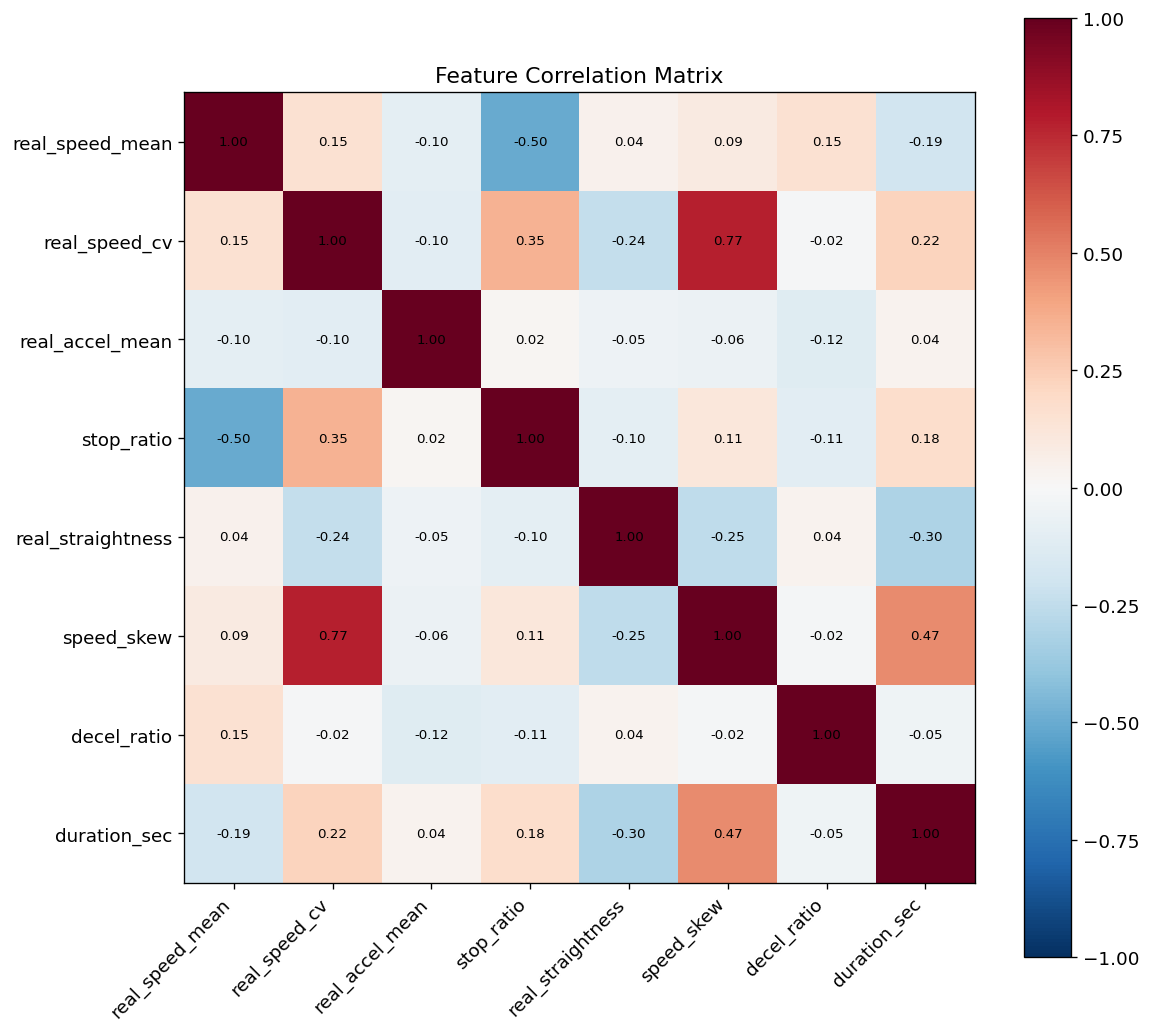

In [27]:
df_r = df.dropna(subset=['real_speed_mean'])
feat_cols = ['real_speed_mean', 'real_speed_cv', 'real_accel_mean',
             'stop_ratio', 'real_straightness', 'speed_skew', 'decel_ratio', 'duration_sec']
corr = df_r[feat_cols].corr()

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(feat_cols)))
ax.set_yticks(range(len(feat_cols)))
ax.set_xticklabels(feat_cols, rotation=45, ha='right')
ax.set_yticklabels(feat_cols)
for i in range(len(feat_cols)):
    for j in range(len(feat_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(output_dir / f'{TARGET_VIDEO}_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Summary

| Feature | Unit | Distribution hypothesis | Rationale |
|---|---|---|---|
| `real_speed_mean` | m/s | **Normal** | Walking speed clusters symmetrically around a mean |
| `real_speed_cv` | — | Log-normal | Relative variability, positive, right-skewed |
| `real_accel_abs_mean` | m/s² | **Half-normal** | |N(0,σ²)| — absolute value of symmetric acceleration |
| `stop_ratio` | — | Beta | Bounded [0, 1] |
| `real_straightness` | — | Beta | Depth-normalized displacement / path length; bounded [0, 1] |
| `speed_skew` | — | **Gamma** | Within-trajectory skewness of per-step speeds; almost always positive (speed floor at 0) |
| `decel_ratio` | — | Beta | Fraction of steps decelerating; bounded [0, 1] |
| `duration_sec` | s | Log-normal | Heavy right tail |

**Depth normalization (all `real_*` features):** `scale = H_REAL / avg_bbox_height`,  H_REAL = 1.7 m  
**Limitation:** Assumes full-body visibility. Breaks down for occluded or crouching persons.  
**Excluded:** Direction (camera angle makes it non-comparable across locations)

These distribution families parameterize the statistical manifold in Article 4.  
Each trajectory → one point in the product parameter space.

## 13. Distribution Summary Table

In [28]:
# ── Distribution candidates per feature type ──────────────────────────────────
# positive_unbounded : norm, lognorm, halfnorm, gamma, expon
# bounded_0_1        : beta, uniform (+ norm/lognorm as references)
# full_real          : norm, laplace, t(df=5), cauchy

from scipy.stats import norm, lognorm, halfnorm, gamma, expon
from scipy.stats import beta as beta_dist, uniform
from scipy.stats import laplace, cauchy, t as t_dist

CANDIDATES = {
    'positive': [
        ('Normal',      norm,     {}),
        ('Log-normal',  lognorm,  {'floc': 0}),
        ('Half-normal', halfnorm, {'floc': 0}),
        ('Gamma',       gamma,    {'floc': 0}),
        ('Exponential', expon,    {'floc': 0}),
    ],
    'bounded': [
        ('Beta',        beta_dist, {'floc': 0, 'fscale': 1}),
        ('Uniform',     uniform,   {'floc': 0, 'fscale': 1}),
        ('Normal',      norm,      {}),
        ('Log-normal',  lognorm,   {'floc': 0}),
    ],
    'full_real': [
        ('Normal',      norm,     {}),
        ('Laplace',     laplace,  {}),
        ('t (df=5)',    t_dist,   {'f0': 5}),
        ('Cauchy',      cauchy,   {}),
    ],
}

FEATURE_META = {
    # name             unit    dtype        clip_quantile
    'real_speed_mean':     ('m/s',  'positive',  0.99),
    'real_speed_std':      ('m/s',  'positive',  0.99),
    'real_speed_cv':       ('—',    'positive',  0.99),
    'real_accel_abs_mean': ('m/s²', 'positive',  0.99),
    'real_accel_mean':     ('m/s²', 'full_real',  None),
    'real_accel_std':      ('m/s²', 'positive',  0.99),
    'real_accel_cv':       ('—',    'positive',  0.99),
    'stop_ratio':          ('—',    'bounded',   None),
    'speed_skew':          ('—',    'full_real',  0.99),
    'real_straightness':   ('—',    'bounded',   None),
    'decel_ratio':         ('—',    'bounded',   None),
    'duration_sec':        ('s',    'positive',  0.99),
}

def prep(series, dtype, clip_q):
    d = series.dropna()
    if dtype == 'bounded':
        return d.clip(0.001, 0.999)
    if dtype == 'full_real':
        if clip_q:
            d = d[d.abs() < d.abs().quantile(clip_q)]
        return d
    # positive
    d = d[d > 0]
    if clip_q:
        d = d[d < d.quantile(clip_q)]
    return d

def fit_and_test(d, dist, fit_kw):
    try:
        params = dist.fit(d, **fit_kw)
        ks, pv = stats.kstest(d, lambda x, p=params, di=dist: di.cdf(x, *p))
        return ks, pv, params
    except Exception:
        return np.nan, np.nan, None

# ── Main fitting loop ─────────────────────────────────────────────────────────
best_fit = {}   # feature -> dict with best distribution info
all_rows = []   # for the full table

for feat, (unit, dtype, clip_q) in FEATURE_META.items():
    if feat not in df_r.columns:
        continue
    d = prep(df_r[feat], dtype, clip_q)
    if len(d) < 10:
        continue

    mean_val = d.mean()
    std_val  = d.std()

    candidates = CANDIDATES[dtype]
    results = []
    for dist_name, dist, fit_kw in candidates:
        ks, pv, params = fit_and_test(d, dist, fit_kw)
        results.append((dist_name, ks, pv, params))
        all_rows.append({
            'Feature':      f'`{feat}`',
            'Unit':         unit,
            'Mean':         f'{mean_val:.3f}',
            'Std':          f'{std_val:.3f}',
            'Distribution': dist_name,
            'KS':           f'{ks:.3f}' if not np.isnan(ks) else '—',
            'p-value':      f'{pv:.3f}' if not np.isnan(pv) else '—',
            'Accept':       ('✓' if pv > 0.05 else '✗') if not np.isnan(pv) else '—',
        })

    # best = lowest KS (primary), highest p (tiebreak)
    valid = [(n, ks, pv, p) for n, ks, pv, p in results if not np.isnan(ks)]
    if valid:
        best_name, best_ks, best_pv, best_params = min(valid, key=lambda x: (x[1], -x[2]))
        best_fit[feat] = {
            'unit':         unit,
            'mean':         round(mean_val, 4),
            'std':          round(std_val,  4),
            'distribution': best_name,
            'ks':           round(best_ks,  4),
            'p_value':      round(best_pv,  4),
            'accepted':     best_pv > 0.05,
        }

print("best_fit dictionary:")
for k, v in best_fit.items():
    print(f"  {k:25s}: {v['distribution']:12s}  KS={v['ks']:.3f}  p={v['p_value']:.3f}  {'✓' if v['accepted'] else '✗'}")

# ── Markdown table (all candidates, best row highlighted with *) ──────────────
cols = ['Feature','Unit','Mean','Std','Distribution','KS','p-value','Accept']
lines = ['| ' + ' | '.join(cols) + ' |',
         '| ' + ' | '.join(['---']*len(cols)) + ' |']

prev_feat = None
for row in all_rows:
    feat_raw = row['Feature'].strip('`')
    is_best  = (feat_raw in best_fit and
                best_fit[feat_raw]['distribution'] == row['Distribution'])
    marker = ' **\*best\***' if is_best else ''
    lines.append('| ' + ' | '.join(
        (row[c] + marker if c == 'Distribution' else row[c]) for c in cols
    ) + ' |')

md_table = '\n'.join(lines)
print('\n' + md_table)


# ── Selected 8 features for manifold construction ────────────────────────────
# real_accel_abs_mean is dropped in favor of real_accel_mean (Cauchy, p=0.937).
# real_speed_std / real_accel_std / real_accel_cv are dropped (redundant or poor fit).

SELECTED_FEATURES = {
    feat: best_fit[feat]
    for feat in [
        'real_speed_mean',
        'real_speed_cv',
        'real_accel_mean',
        'stop_ratio',
        'speed_skew',
        'real_straightness',
        'decel_ratio',
        'duration_sec',
    ]
    if feat in best_fit
}

print("\n── Selected features for Article 4 manifold ──")
print(f"{'Feature':<25} {'Distribution':<14} {'KS':>6}  {'p':>6}  Accept")
print("-" * 60)
for feat, v in SELECTED_FEATURES.items():
    print(f"{feat:<25} {v['distribution']:<14} {v['ks']:>6.3f}  {v['p_value']:>6.3f}  {'✓' if v['accepted'] else '✗ (best KS)'}") 


<>:128: SyntaxWarning: invalid escape sequence '\*'
<>:128: SyntaxWarning: invalid escape sequence '\*'
C:\Users\tokit\AppData\Local\Temp\ipykernel_43900\698318994.py:128: SyntaxWarning: invalid escape sequence '\*'
  marker = ' **\*best\***' if is_best else ''


best_fit dictionary:
  real_speed_mean          : Gamma         KS=0.037  p=0.350  ✓
  real_speed_std           : Log-normal    KS=0.058  p=0.033  ✗
  real_speed_cv            : Log-normal    KS=0.061  p=0.019  ✗
  real_accel_abs_mean      : Log-normal    KS=0.035  p=0.447  ✓
  real_accel_mean          : Cauchy        KS=0.028  p=0.699  ✓
  real_accel_std           : Log-normal    KS=0.069  p=0.006  ✗
  real_accel_cv            : Log-normal    KS=0.140  p=0.000  ✗
  stop_ratio               : Beta          KS=0.118  p=0.000  ✗
  speed_skew               : t (df=5)      KS=0.094  p=0.000  ✗
  real_straightness        : Normal        KS=0.069  p=0.005  ✗
  decel_ratio              : Log-normal    KS=0.055  p=0.043  ✗
  duration_sec             : Gamma         KS=0.045  p=0.161  ✓

| Feature | Unit | Mean | Std | Distribution | KS | p-value | Accept |
| --- | --- | --- | --- | --- | --- | --- | --- |
| `real_speed_mean` | m/s | 1.360 | 0.420 | Normal | 0.045 | 0.165 | ✓ |
| `real_speed_me

In [29]:
out_path = DATA_DIR.parent / f'{TARGET_VIDEO}_features.csv'
df.to_csv(out_path, index=False)
print(f"Saved: {out_path}  ({df.shape[0]} rows × {df.shape[1]} cols)")

Saved: ..\output\2394_features.csv  (618 rows × 15 cols)
